In Formula 1, a pit stop is a moment during the race when a driver enters the pit lane, usually to change tyres. In this notebook, I predict the variable PitNextLap - whether a driver will make a pit stop on the next lap.
The dataset contains race statistics such as the race location, year, driver, tyre compound, lap time, tyre life, and race progress. After exploratory data analysis and preprocessing (including one-hot encoding of categorical variables), I trained a Random Forest classifier which achieved an AUC of 0.921.

### Import and configuration

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


### Load data

In [2]:
train_data=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test_data=pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")

### EDA

In [3]:
train_data.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [5]:
train_data.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [6]:
train_data["PitNextLap"].value_counts()

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

As we can see, the dataset is imbalanced - there are significantly more laps without a pit stop (0: 351,759) than laps with a pit stop (1: 87,381). This means that pit stops are relatively rare events, occurring in only about 20% of laps.

Text(0.5, 0, 'PitNextLap')

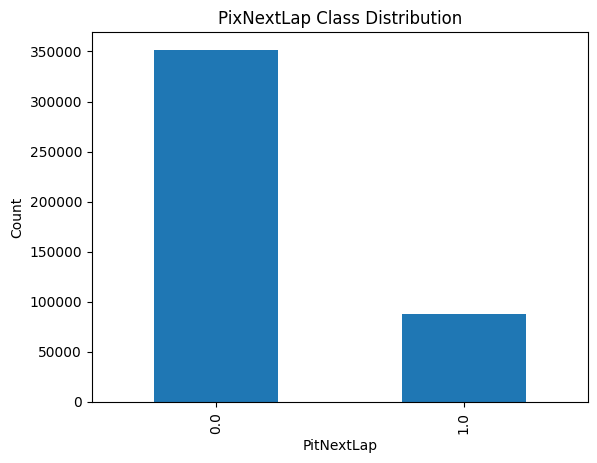

In [7]:
train_data["PitNextLap"].value_counts().plot(kind='bar')
plt.title("PixNextLap Class Distribution")
plt.ylabel('Count')
plt.xlabel('PitNextLap')

The dataset is imbalanced - around 80% of laps do not result in a pit stop (0), while only 20% do (1).

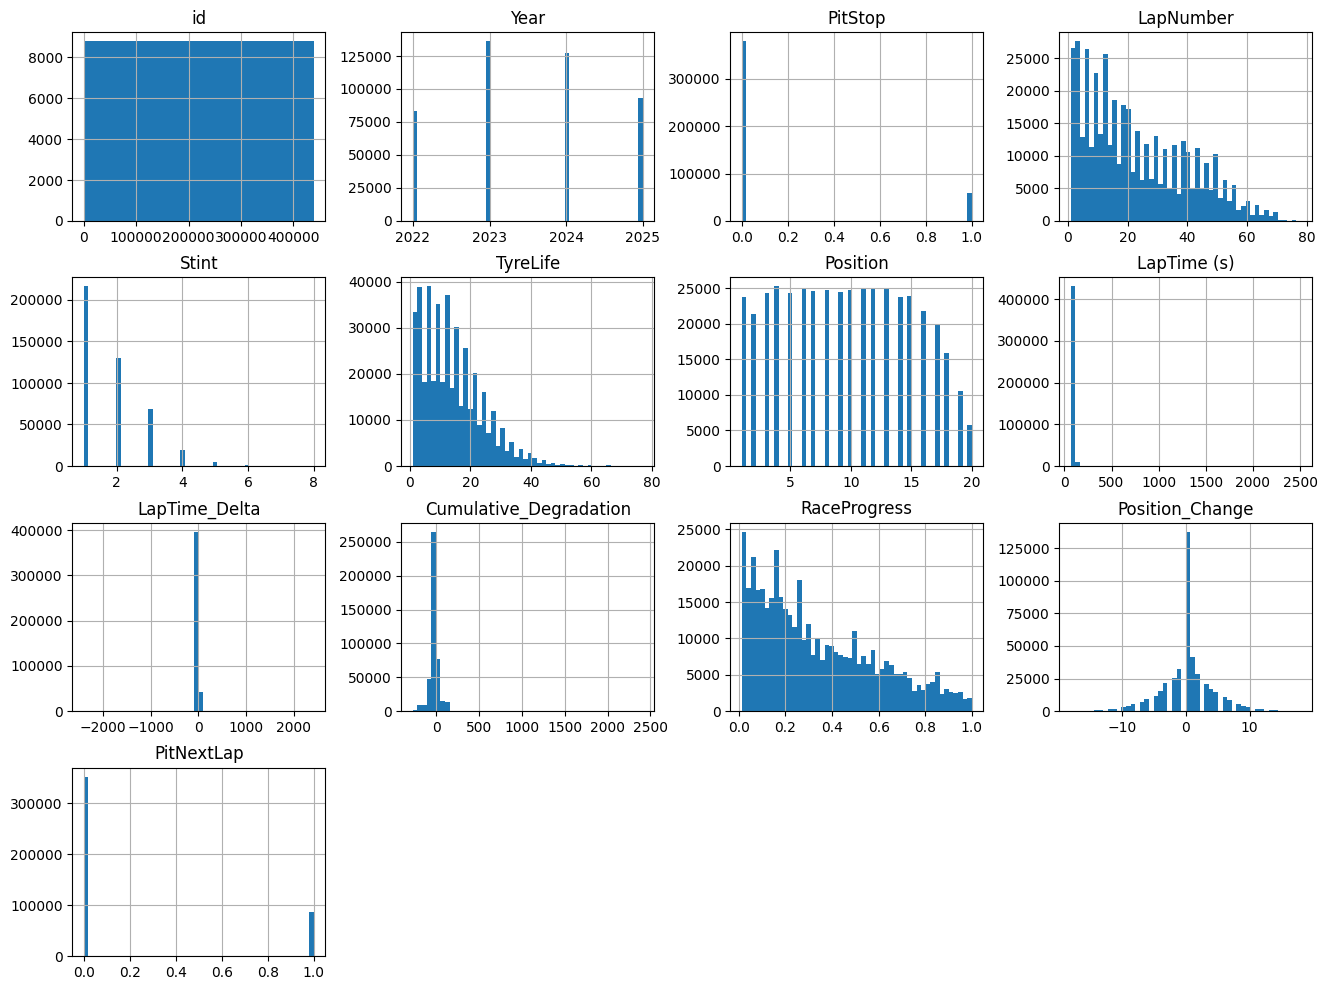

In [8]:
train_data.hist(bins=50, figsize=(16,12))
plt.show()

### Data Preparation

I am not including the id and PitStop variables in features - id does not contain any useful information about pit stop prediction, and PitStop could lead to data leakage as it indicates whether a pit stop occurred on the current lap.

In [9]:
features=["Year", "LapNumber", "Stint", "TyreLife", "Position", "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "RaceProgress", "Position_Change"]

In [10]:
target="PitNextLap"

We use One-Hot Encoding for the Compound and Race columns because they are categorical variables. Compound is particularly important as it holds information about the tyre type used, which is directly related to pit stop strategy. Race encodes the track location, which may also influence pit stop timing.

In [11]:
one_hot_encoder=OneHotEncoder(sparse_output=False)

In [12]:
train_data_one_hot=one_hot_encoder.fit_transform(train_data[ ['Compound', 'Race']])

In [13]:
train_data_one_hot

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [14]:
test_data_one_hot=one_hot_encoder.transform(test_data[['Compound', 'Race']])

In [15]:
test_data_one_hot

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [16]:
X, y=train_data[features].values, train_data[target].values

In [17]:
X=np.hstack((X, train_data_one_hot))

I split the data in a 70/30 ratio using train_test_split with random_state=42 to ensure reproducibility. This means 70% of the data is used for training and 30% for validation.

In [18]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.3, random_state=42)

### Selecting and training model

I used RandomForestClassifier with max_depth=10 and random_state=42. I chose Random Forest over Logistic Regression because it is a non-linear model that can capture more complex relationships in the data, which resulted in a significantly better AUC score (0.921 vs 0.838).

In [19]:
model=RandomForestClassifier(max_depth=10, random_state=42 ).fit(X_train, y_train)

In [20]:
predictions=model.predict(X_test)

In [21]:
print('Predicted labels: ', predictions)

Predicted labels:  [0. 0. 0. ... 0. 0. 1.]


In [22]:
print(f"Accuracy score: {accuracy_score(y_test, predictions)*100:.2f}%")
print(f"Overall precision: {precision_score(y_test, predictions)*100:.2f}%")
print(f"Overall recall: {recall_score(y_test, predictions)*100:.2f}%")

Accuracy score: 87.71%
Overall precision: 72.85%
Overall recall: 60.88%


In [23]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.91      0.94      0.92    105541
         1.0       0.73      0.61      0.66     26201

    accuracy                           0.88    131742
   macro avg       0.82      0.78      0.79    131742
weighted avg       0.87      0.88      0.87    131742



In [24]:
y_score=model.predict_proba(X_test)
y_score

array([[0.9777821 , 0.0222179 ],
       [0.97895599, 0.02104401],
       [0.97456348, 0.02543652],
       ...,
       [0.95078143, 0.04921857],
       [0.98409407, 0.01590593],
       [0.33831163, 0.66168837]])

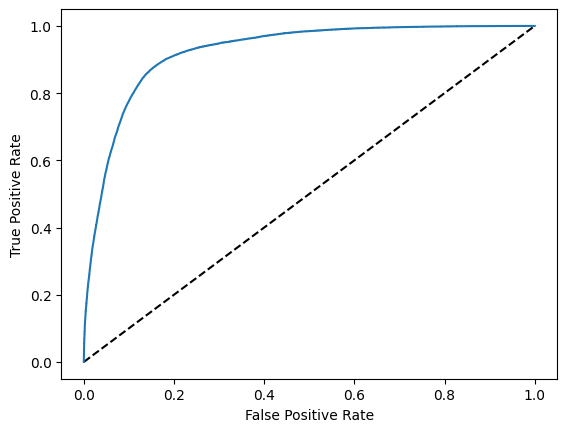

In [25]:
fpr, tpr, thresholds=roc_curve(y_test, y_score[:,1])
fig=plt.figure()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [26]:
auc=roc_auc_score(y_test, y_score[:, 1])
print('AUC: ', auc)

AUC:  0.9239294088836272


In [27]:
test_data_prepared=test_data[features].values

In [28]:
test_data_prepared=np.hstack((test_data_prepared, test_data_one_hot))

In [29]:
y_score_submission=model.predict_proba(test_data_prepared)
y_score_submission

array([[0.98668848, 0.01331152],
       [0.97687062, 0.02312938],
       [0.98104388, 0.01895612],
       ...,
       [0.41320767, 0.58679233],
       [0.40166209, 0.59833791],
       [0.9563211 , 0.0436789 ]])

In [30]:
my_submission = pd.DataFrame({'id': test_data.id, 'PitNextLap': y_score_submission[:,1]})
my_submission.to_csv('submission.csv', index=False)

I achieved an AUC of 0.923 on validation and 0.921 on Kaggle public leaderboard. The biggest improvements came from adding Compound and Race features with One-Hot Encoding, and switching from Logistic Regression to Random Forest. To improve this result further, one could tune hyperparameters such as max_depth using the elbow method, or apply feature engineering to create new meaningful variables.